# Stochastic evolution of a colony of B cells

In [721]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng

In [ ]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""


p_sil=0.8# 0.8   
p_let=0.05*(1-p_sil)
p_aa=0.95*(1-p_sil)
T=140
E_a=3.4                        # Ag-gate threshold
kBT=1                       # thermal factor
N_i=2000  
N_max=2000 
mu_i=0.0 
sigma_i=0.05
p_diff=0.10
c=800# 800

# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# --

In [723]:
# ----------------------- one maturation round --------------------------
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator,
             mu_M: np.ndarray,
             sigma_M: np.ndarray,
             mutable_positions=None) -> tuple[np.ndarray, np.ndarray]:

    # sanity
    N_h = pop.shape[1]
    assert mu_M.shape == (N_h,) and sigma_M.shape == (N_h,), "mu_M and sigma_M must be length N_h"

    # 1 Duplication ------------------------------------------------------
    pop = np.repeat(pop, 2, axis=0)  # each cell divides

    # 2 Somatic hyper-mutation ------------------------------------------
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])

    alive_mask = fate != "let"
    aa_mask    = fate == "aa"

    if aa_mask.any():
        # rows of cells that mutate
        rows = np.flatnonzero(aa_mask)                  # shape (n_aa,)
        if mutable_positions is None:
        # choose exactly one site per mutating cell
            idx_sites = rng.integers(0, N_h, size=rows.size)  # shape (n_aa,)
        else:
            # mutable_positions should be a list or array of allowed site indices
            idx_sites = rng.choice(mutable_positions, size=rows.size)

        # draw per-site effects: Δh_j ~ N(mu_M[i_j], sigma_M[i_j])
        locs   = mu_M[idx_sites]                        # (n_aa,)
        scales = sigma_M[idx_sites]                     # (n_aa,)
        delta_h = rng.normal(locs, scales)              # (n_aa,)

        # apply paired updates (row j, column i_j)
        pop[rows, idx_sites] = np.clip(pop[rows, idx_sites] + delta_h, -6, 2)

    pop = pop[alive_mask]
    if pop.size == 0:
        return pop, np.empty((0, N_h))

    # 3 Antigen-binding gate --------------------------------------------
    eps     = energies(pop, S_mat)
    P_ag    = P_Ag(eps, C_vec)
    survive = rng.random(size=P_ag.size) < P_ag
    pop     = pop[survive];  eps = eps[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h))

    # 4 T-cell-help gate -------------------------------------------------
    P_t     = P_T(eps, C_vec)
    survive = rng.random(size=P_t.size) < P_t
    pop     = pop[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h))

    # 5 Differentiation --------------------------------------------------
    diff_mask = rng.random(size=pop.shape[0]) < p_diff
    mem_cells = pop[diff_mask]
    pop       = pop[~diff_mask]

    return pop, mem_cells

def simulate_gc_history(rounds: int,
                        S_mat: np.ndarray,
                        N_init: int = N_i,
                        N_max: int  = N_max,
                        C_schedule = lambda: np.array([c]),
                        mu_init: float = mu_i,
                        sigma_init: float = sigma_i,
                        mu_M: np.ndarray | None = None,
                        sigma_M: np.ndarray | None = None,
                        mutable_positions=None,
                        seed: int | None = None) -> list[np.ndarray]:

    rng = default_rng(seed)
    N_h = S_mat.shape[0]

    if mu_M is None or sigma_M is None:
        raise ValueError("Provide per-site mu_M and sigma_M of shape (N_h,)")

    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    mutable_positions = np.array(mutable_positions, dtype=int)  # indices of mutable sites
    all_positions = np.arange(N_h)
    non_mutable_positions = np.setdiff1d(all_positions, mutable_positions)

    pop[:, non_mutable_positions] = 0.0
    history: list[np.ndarray] = [pop.copy()]

    for _ in range(rounds):
        C_vec = np.asarray(C_schedule(), dtype=float)
        pop, _mem = gc_round(pop, S_mat, C_vec, rng, mu_M, sigma_M,mutable_positions=mutable_positions)

        if pop.shape[0] > N_max:
            keep_idx = rng.choice(pop.shape[0], N_max, replace=False)
            pop = pop[keep_idx]

        history.append(pop.copy())

    return history


In [724]:
def plot_h_dimension(history, dim_idx=0, h_min=-4, h_max=10, n_hbins=100, t_clip=50, cmap="Greys_r"):
    """
    Plot the density of B-cell h[dim_idx] values over rounds with fixed colorbar scale [0, 500].
    """
    time_points = []
    h_values = []
    for t, pop in enumerate(history):
        if pop.size == 0:
            continue
        time_points.extend([t] * pop.shape[0])
        h_values.extend(pop[:, dim_idx])

    rounds_arr = np.asarray(time_points)
    h_vals     = np.asarray(h_values)

    n_rounds   = len(history)
    round_bins = np.linspace(rounds_arr.min(), rounds_arr.max(), n_rounds + 1)
    h_bins     = np.linspace(h_min, h_max, n_hbins + 1)

    H, xedges, yedges = np.histogram2d(rounds_arr, h_vals, bins=[round_bins, h_bins])

    plt.figure(figsize=(8, 5))
    im = plt.imshow(H.T, origin="lower", aspect="auto",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                    cmap=cmap, vmin=0.0, vmax=100)  # fixed scale
    plt.xlabel("Round")
    plt.ylabel(rf"$h_{{{dim_idx+1}}}$")
    plt.title(rf"Density of B-cells in $h_{{{dim_idx+1}}}$ over GC rounds")
    plt.colorbar(im, label="Density")
    plt.ylim(h_min, h_max)
    plt.tight_layout()
    plt.show()

# Example




len 233
EVQLQESGPSLVKPSQTLSLTCSVTGDSITSGYWNWIRKFPGNKLEYMGYISYSGSTYYNPSLKSRISITRDTSKNQYYLQLNSVTTEDTATYYCARDFDVWGAGTTVTVSSGGGGSGGGSGGGSDIVMTQSQKFMSTSVGDRVSVTCKASQNVGTNVAWYQQKPGQSPKALIYSASYRYSGVPDRFTGSGSGTDFTLTISNVQSEDLAEYFCQQYNSYPLTFGSGTKLEIKR
220
[ 3.44696988e-01  2.14600931e-02  1.05448529e-01  2.44465459e-01
  1.36697898e-01  1.91374426e-01  7.82832880e-02  1.06987314e-01
  2.14528564e-01  5.77126507e-02  6.33112218e-02  7.46766722e-02
  4.83246823e-02  1.65940729e-01  2.00143986e-01  8.88896528e-02
  3.54022458e-02 -4.22493663e-01  2.51343610e-02 -3.87130342e-01
 -1.65847529e-01 -1.62481917e+00 -1.52542973e-01 -9.89397789e-01
 -3.27772988e-02  2.21031722e-01  1.26389759e+00  1.69601839e-01
 -7.12051414e-01 -3.07314519e-01 -5.29462995e-02 -1.51018662e+00
 -3.14495296e+00 -3.03717882e+00 -1.78031850e+00 -4.05941914e-01
 -1.55210929e+00 -1.48396620e+00 -2.67751173e-01  1.03122918e-01
  1.60542811e-01 -6.78188063e-02 -2.03315385e-01 -7.28505029e-02
  2.97987405e-02  4.98575461e-02 -3.003

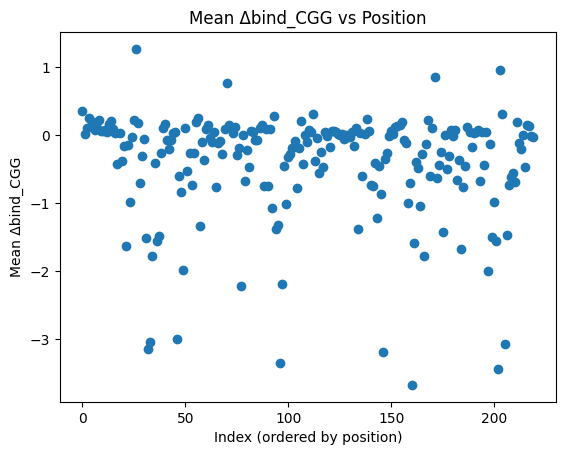

In [725]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data_mat/final_variant_scores.csv')
# Group by position, take the first wildtype amino acid for each position
wt_seq = (
    df.groupby("position")["wildtype"]
      .first()
      .sort_index()
      .str.cat()
)
print('len',len(wt_seq))

print(wt_seq)

df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
df = df[df["single_nt"]]  # keep only single-nt rows
df['position'] = df['position'] - 1

# Group and compute mean/std
stats = df.groupby(["position", "annotation"])["delta_bind_CGG"].agg(["mean", "std"]).reset_index()

# Arrays (ordered by position)
positions = stats["position"].to_numpy()
mu_arr = stats["mean"].to_numpy() * np.log(10)
sigma_arr = stats["std"].to_numpy() * np.log(10)

print(len(positions))
print(mu_arr)
print(sigma_arr)

# Save CSV
stats_out = stats.copy()
stats_out["mean"] = stats_out["mean"] * np.log(10)
stats_out["std"] = stats_out["std"] * np.log(10)
# stats_out.to_csv("annotation_position_mean_std.csv", index=False)

# Plot
plt.scatter(np.arange(len(mu_arr)), mu_arr)
plt.xlabel("Index (ordered by position)")
plt.ylabel("Mean Δbind_CGG")
plt.title("Mean Δbind_CGG vs Position")
plt.show()


In [726]:
print(df.annotation.unique())
# Keep only unique (position, annotation) pairs
pos_annotation_dict = (
    df.drop_duplicates(subset=["position", "annotation"])
      .set_index("position")["annotation"]
      .to_dict()
)

print(pos_annotation_dict)
cdr_positions = (
    df[df["annotation"].str.contains("CDR", na=False)]
    .drop_duplicates(subset=["position"])
    [["position"]]
    .to_records(index=False)
    .tolist()
)
cdr_positions=[pos[0] for pos in cdr_positions]
print(cdr_positions)#absolute position
#i need index of cdr_positions inside position array
cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

print(cdr_positions_relative)

['FWRH1' 'CDRH1' 'FWRH2' 'CDRH2' 'FWRH3' 'CDRH3' 'FWRH4' 'FWRL1' 'CDRL1'
 'FWRL2' 'CDRL2' 'FWRL3' 'CDRL3' 'FWRL4']
{0: 'FWRH1', 1: 'FWRH1', 2: 'FWRH1', 3: 'FWRH1', 4: 'FWRH1', 5: 'FWRH1', 6: 'FWRH1', 7: 'FWRH1', 8: 'FWRH1', 9: 'FWRH1', 10: 'FWRH1', 11: 'FWRH1', 12: 'FWRH1', 13: 'FWRH1', 14: 'FWRH1', 15: 'FWRH1', 16: 'FWRH1', 17: 'FWRH1', 18: 'FWRH1', 19: 'FWRH1', 20: 'FWRH1', 21: 'FWRH1', 22: 'FWRH1', 23: 'FWRH1', 24: 'FWRH1', 25: 'CDRH1', 26: 'CDRH1', 27: 'CDRH1', 28: 'CDRH1', 29: 'CDRH1', 30: 'CDRH1', 31: 'CDRH1', 32: 'CDRH1', 33: 'FWRH2', 34: 'FWRH2', 35: 'FWRH2', 36: 'FWRH2', 37: 'FWRH2', 38: 'FWRH2', 39: 'FWRH2', 40: 'FWRH2', 41: 'FWRH2', 42: 'FWRH2', 43: 'FWRH2', 44: 'FWRH2', 45: 'FWRH2', 46: 'FWRH2', 47: 'FWRH2', 48: 'FWRH2', 49: 'CDRH2', 50: 'CDRH2', 51: 'CDRH2', 52: 'CDRH2', 53: 'CDRH2', 54: 'CDRH2', 55: 'CDRH2', 56: 'CDRH2', 57: 'FWRH3', 58: 'FWRH3', 59: 'FWRH3', 60: 'FWRH3', 61: 'FWRH3', 62: 'FWRH3', 63: 'FWRH3', 64: 'FWRH3', 65: 'FWRH3', 66: 'FWRH3', 67: 'FWRH3', 68: 'FWRH3

In [727]:
len(mu_arr)

220

In [728]:

# Turn your scalar params into per-site vectors (or set site-specific values here)
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
def C_schedule():
    return np.array([c])

history = simulate_gc_history(
    rounds      = T,
    S_mat       = S_mat,
    N_init      = N_i,
    N_max       = N_max,
    C_schedule  = C_schedule,
    mu_M        = mu_arr,
    sigma_M     = sigma_arr,
    mutable_positions=cdr_positions_relative,
    seed        = 42
)

print(f"Rounds simulated: {len(history)-1}")
for t, pop in enumerate(history):
    print(f"t={t:02d}  cycling cells={pop.shape[0]}")


Nh 220
Rounds simulated: 140
t=00  cycling cells=2000
t=01  cycling cells=2000
t=02  cycling cells=2000
t=03  cycling cells=2000
t=04  cycling cells=2000
t=05  cycling cells=2000
t=06  cycling cells=2000
t=07  cycling cells=2000
t=08  cycling cells=2000
t=09  cycling cells=2000
t=10  cycling cells=2000
t=11  cycling cells=2000
t=12  cycling cells=2000
t=13  cycling cells=2000
t=14  cycling cells=2000
t=15  cycling cells=2000
t=16  cycling cells=2000
t=17  cycling cells=2000
t=18  cycling cells=2000
t=19  cycling cells=2000
t=20  cycling cells=2000
t=21  cycling cells=2000
t=22  cycling cells=2000
t=23  cycling cells=2000
t=24  cycling cells=2000
t=25  cycling cells=2000
t=26  cycling cells=2000
t=27  cycling cells=2000
t=28  cycling cells=2000
t=29  cycling cells=2000
t=30  cycling cells=2000
t=31  cycling cells=2000
t=32  cycling cells=2000
t=33  cycling cells=2000
t=34  cycling cells=2000
t=35  cycling cells=2000
t=36  cycling cells=2000
t=37  cycling cells=2000
t=38  cycling cells=2

In [729]:

# Example


# Example: plot the first dimension h[0]
# plot_h_dimension(history, dim_idx=0)
# plot_h_dimension(history, dim_idx=26)
# plot_h_dimension(history, dim_idx=27)


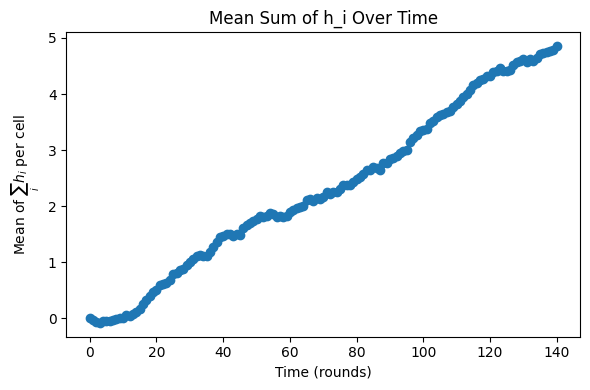

In [730]:
import numpy as np
import matplotlib.pyplot as plt

# history is a list of arrays: one array per time point, shape (n_cells_t, N_h)

mean_sum_hi_per_time = []

for pop in history:
    if pop.size == 0:
        mean_sum_hi_per_time.append(np.nan)  # handle empty population
    else:
        sum_hi_per_cell = pop.sum(axis=1)  # sum over h_i for each cell
        mean_sum_hi_per_time.append(sum_hi_per_cell.mean())  # average over cells

times = np.arange(len(history))

plt.figure(figsize=(6, 4))
plt.plot(times, mean_sum_hi_per_time, marker='o')
plt.xlabel("Time (rounds)")
plt.ylabel(r"Mean of $\sum_i h_i$ per cell")
plt.title("Mean Sum of h_i Over Time")
plt.tight_layout()
plt.show()


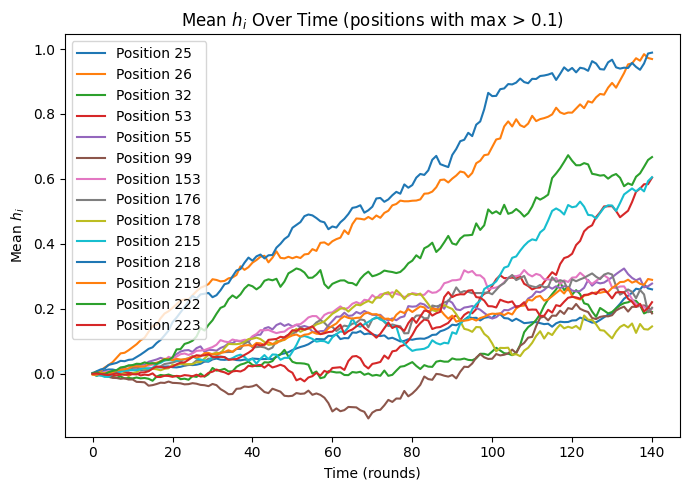

In [731]:
import numpy as np
import matplotlib.pyplot as plt

# Determine N_h from first timepoint
N_h = history[0].shape[1]

# Compute mean h_i per time for each position
mean_hi_per_time = np.zeros((len(history), N_h))

for t, pop in enumerate(history):
    if pop.size == 0:
        mean_hi_per_time[t, :] = np.nan
    else:
        mean_hi_per_time[t, :] = pop.mean(axis=0)

# Filter positions with max value > 0.1
mask = (np.nanmax(mean_hi_per_time, axis=0) > 0.2)
selected_positions = np.where(mask)[0]

# Plot each selected position
plt.figure(figsize=(7, 5))
for i in selected_positions:
    plt.plot(np.arange(len(history)), mean_hi_per_time[:, i], label=f"Position {positions[i]}")

plt.xlabel("Time (rounds)")
plt.ylabel(r"Mean $h_i$")
plt.title("Mean $h_i$ Over Time (positions with max > 0.1)")
plt.legend()
plt.tight_layout()
plt.show()


In [732]:
import pandas as pd

# Times of interest
times_of_interest = np.array([5, 8, 11, 14, 17, 20, 70])*2

# Build a DataFrame
records = []
for i in range(N_h):
    for t in times_of_interest:
        if t < len(history):  # avoid out-of-bounds
            records.append({
                "position": positions[i],
                "time": t,
                "mean_hi": mean_hi_per_time[t, i]
            })

df_out = pd.DataFrame(records)

# Save to CSV
df_out.to_csv("mean_hi_stochastic.csv", index=False)
print("Saved mean h_i values for selected times to mean_hi_stochastic.csv")


Saved mean h_i values for selected times to mean_hi_stochastic.csv


In [733]:
stop()

NameError: name 'stop' is not defined

# Linages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

# ----------------------------------------------------------------------


# ----------------------------------------------------------------------
def energies(h_mat, S_mat):
    return h_mat @ S_mat

def P_Ag(eps, C_vec):
    exp_term = np.exp((eps - E_a) / kBT)
    numer = (exp_term * C_vec).sum(axis=1)
    return numer / (1.0 + numer)

def P_T(eps, C_vec):
    C_tot = C_vec.sum()
    Phi = (np.exp(eps / kBT) * C_vec).sum(axis=1)
    Phi_bar = Phi.mean()
    return Phi / (Phi + Phi_bar / C_tot)

# ----------------------------------------------------------------------
def simulate_with_genealogy(rounds,
                            S_mat,
                            C_schedule,
                            N_init=N_i, N_max=N_max,
                            mu_init=mu_i, sigma_init=sigma_i,
                            seed=None):
    """
    Returns
    -------
    history : list[dict]      snapshot r   → {cell_id: h_vec}
    parents : dict            child_id → parent_id (root parents not included)
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]

    # initial repertoire
    pop_h = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    pop_id = np.arange(N_init)               # 0..N_init-1
    next_id = N_init

    parents = {}                             # genealogy graph
    history = [dict(zip(pop_id, pop_h.copy()))]  # round 0 snapshot

    for r in range(rounds):
        # ------ duplication -------------------------------------------------
        pop_h = np.repeat(pop_h, 2, axis=0)          # (2N, N_h)
        parent_ids = np.repeat(pop_id, 2)            # (2N,)

        new_ids = np.arange(next_id, next_id + pop_h.shape[0])
        next_id += pop_h.shape[0]
        # register genealogy
        parents.update({cid: pid for cid, pid in zip(new_ids, parent_ids)})

        pop_id = new_ids                              # adopt new IDs

        # ------ somatic hyper‑mutation -------------------------------------
        fate = rng.choice(["let", "aa", "sil"], size=pop_h.shape[0],
                          p=[p_let, p_aa, p_sil])
        alive_mask = fate != "let"
        aa_mask = fate == "aa"
        if aa_mask.any():
            idx = rng.integers(0, N_h, size=aa_mask.sum())
            pop_h[aa_mask, idx] = np.clip(pop_h[aa_mask, idx]+rng.normal(mu_M, sigma_M, size=aa_mask.sum()),-10, 10)

        pop_h, pop_id = pop_h[alive_mask], pop_id[alive_mask]
        if pop_h.size == 0:
            history.append({})          # empty snapshot
            break

        # ------ Ag binding gate --------------------------------------------
        eps = energies(pop_h, S_mat)
        survive = rng.random(pop_h.shape[0]) < P_Ag(eps, C_schedule())
        pop_h, pop_id, eps = pop_h[survive], pop_id[survive], eps[survive]
        if pop_h.size == 0:
            history.append({})
            break

        # ------ T‑cell help gate -------------------------------------------
        survive = rng.random(pop_h.shape[0]) < P_T(eps, C_schedule())
        pop_h, pop_id = pop_h[survive], pop_id[survive]
        if pop_h.size == 0:
            history.append({})
            break

        # ------ differentiation (exit GC) ----------------------------------
        stay = rng.random(pop_h.shape[0]) >= p_diff
        pop_h, pop_id = pop_h[stay], pop_id[stay]

        # ------ GC size cap -------------------------------------------------
        if pop_h.shape[0] > N_max:
            keep_idx = rng.choice(pop_h.shape[0], N_max, replace=False)
            pop_h, pop_id = pop_h[keep_idx], pop_id[keep_idx]

        history.append(dict(zip(pop_id, pop_h.copy())))

    return history, parents

# ----------------------------------------------------------------------
def lineage_trajectory(leaf_id, history, parents):
    """
    Reconstruct (round, h1) along the lineage of `leaf_id`.
    Assumes exactly one division per round.
    """
    rounds = []
    h1_vals = []
    cid = leaf_id
    for r in range(len(history)-1, -1, -1):   # from last to first
        snapshot = history[r]
        if cid not in snapshot:
            # lineage ancestor was already dead -> stop
            break
        rounds.append(r)
        h1_vals.append(snapshot[cid][0])      # h1 coordinate
        cid = parents.get(cid, None)          # climb to parent
        if cid is None:
            break
    rounds.reverse()
    h1_vals.reverse()
    return rounds, h1_vals

# ----------------------------------------------------------------------
# Example run -----------------------------------------------------------
S_mat = np.array([[1], [1]])
def C_schedule():
    return np.array([c])

history, parents = simulate_with_genealogy(
    rounds=T,
    S_mat=S_mat,
    C_schedule=C_schedule,
    seed=1
)

# pick leaves meeting threshold
target = 0
leaf_ids = [cid for cid, h in history[-1].items() if target+0.5>=h[0] >= target-0.5]
print(f"Leaves meeting h1 ≥ {target}: {len(leaf_ids)}")

# plot trajectories
t_max = len(history) - 1



In [ ]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- PRL-style font and layout settings ------------------------------
rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 2.6),  # ~8.6cm × 6.6cm
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# --- Load trajectory from CSV ----------------------------------------
h_sol = np.loadtxt("../multi Ag/trajectory_h_140.csv", delimiter=",")
T = 140
n_points = len(h_sol)
t_sol = np.linspace(0, T, n_points)

# --- Prepare B-cell lineage trajectories ------------------------------
h1_by_round = defaultdict(list)
fig, ax = plt.subplots()
first = True

for cid in leaf_ids:
    rounds, h1 = lineage_trajectory(cid, history, parents)
    for t, h in zip(rounds, h1):
        h1_by_round[t].append(h)
    if first:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey', label='Stochastic')
        first = False
    else:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey')

# --- Plot mean trajectory in blue -------------------------------------
common_rounds = sorted(h1_by_round.keys())
mean_h1 = [np.mean(h1_by_round[t]) for t in common_rounds]
ax.plot(common_rounds, mean_h1, lw=1.5, color='blue', label='Mean stochastic')

# --- Plot least-action trajectory in red ------------------------------
ax.plot(t_sol, h_sol, lw=1.5, color='red', label='Least-action')

# --- Final formatting -------------------------------------------------
ax.set_xlim(0, t_max)
ax.set_xlabel("Round")
ax.set_ylabel(r"$h_1$")
ax.legend(frameon=False, loc="upper left")
ax.set_title(r"Lineages reaching $h_1 \sim {}$".format(target))
fig.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sample data resembling schematic trajectory -------------------------
t = np.arange(9)
h = np.array([0.5, 0.8, 0.6, 1.0, 1.2, 1.1, 1.3, 1.35, 1.38])  # example h₁,t values

# --- Create plot ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.2, 2.2))  # PRL single column sizing

# Plot points and lines
ax.plot(t, h, 'k-', marker='o', markersize=5, linewidth=1.5)

# Vertical time ticks
for ti in t:
    ax.axvline(ti, color='grey', alpha=0.3, linestyle='-', zorder=0)

# Label each point with h_{1,t_i}
for i, (ti, hi) in enumerate(zip(t, h)):
    label = r"$h_{1,t_{%d}}$" % i if i not in [0, len(t)-1] else (
        r"$h_{1,t_0}$" if i == 0 else r"$h_{1,t_r}$")
    ax.text(ti, hi + 0.07, label, ha='center', va='bottom', fontsize=8)

# Time axis labels
ax.set_xticks(t)
xticklabels = [r"$t_0$", r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_{r-1}$", r"$t_r$"]
ax.set_xticklabels(xticklabels, rotation=0)

# Axes labels
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$h_1$")

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Delta t annotation
ax.annotate(r"$\delta t$",
            xy=(0.9, 1.5), xytext=(2.4, 1.5),
            arrowprops=dict(arrowstyle='<->', lw=1),
            ha='center', va='center', fontsize=9)

# Format
ax.tick_params(direction='in')
ax.set_xlim(-0.5, t[-1] + 0.5)
ax.set_ylim(0.3, 1.6)
fig.tight_layout()
plt.show()
